--- Loading and Sorting Saved Data ---
Data sorted and aligned successfully! Generating Graphs...



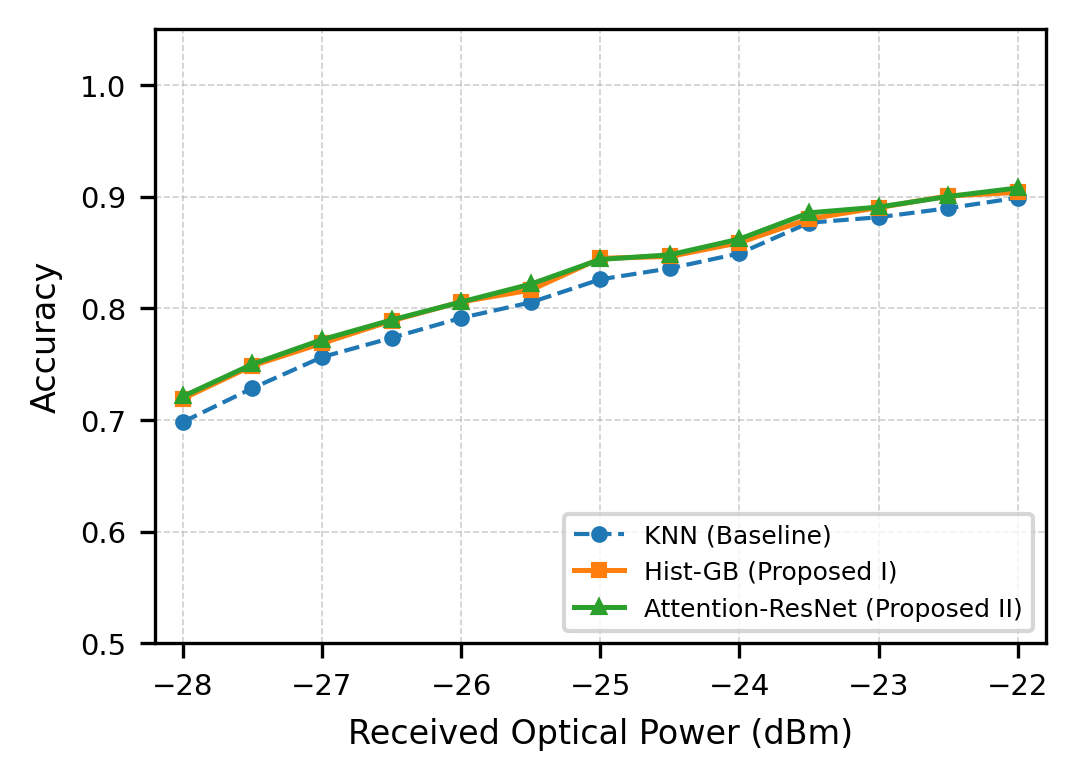

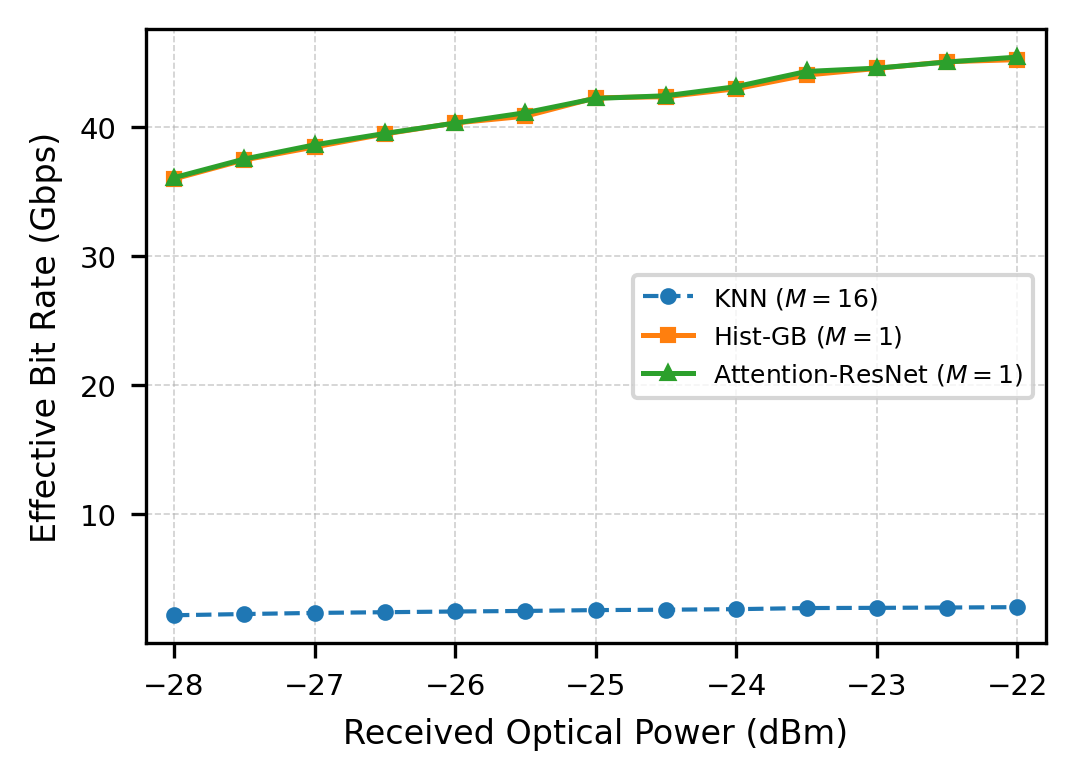

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------- GLOBAL SETTINGS (IEEE STYLE) ----------------
plt.rcParams.update({
    'font.size': 7,
    'axes.labelsize': 8,
    'legend.fontsize': 6,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7
})

print("--- Loading and Sorting Saved Data ---")

try:
    ml_data = pd.read_csv('/content/ML_Results_For_Graph.csv')
    dl_data = pd.read_csv('/content/DL_Results_For_Graph.csv')

    ml_data = ml_data.sort_values(by='ROP_Level').reset_index(drop=True)
    dl_data = dl_data.sort_values(by='ROP_Level').reset_index(drop=True)

    rop_levels = ml_data['ROP_Level']

    acc_knn = ml_data['KNN_Accuracy']
    acc_gb = ml_data['GB_Accuracy']
    acc_adv_cnn = dl_data['Advanced_CNN_Accuracy']

    print("Data sorted and aligned successfully! Generating Graphs...\n")
except FileNotFoundError:
    print("ERROR: Could not find the CSV files. Please make sure both are uploaded!")

# =========================================================
# FIGURE 4: Accuracy vs ROP
# =========================================================
plt.figure(figsize=(3.5, 2.5), dpi=300)

plt.plot(rop_levels, acc_knn, marker='o', linestyle='--', linewidth=1, markersize=3,
         label='KNN (Baseline)')
plt.plot(rop_levels, acc_gb, marker='s', linestyle='-', linewidth=1.2, markersize=3,
         label='Hist-GB (Proposed I)')
plt.plot(rop_levels, acc_adv_cnn, marker='^', linestyle='-', linewidth=1.2, markersize=3,
         label='Attention-ResNet (Proposed II)')

plt.xlabel('Received Optical Power (dBm)')
plt.ylabel('Accuracy')

plt.grid(True, linestyle='--', linewidth=0.4, alpha=0.6)
plt.legend(loc='lower right', frameon=True)

plt.ylim(0.5, 1.05)
plt.xlim(rop_levels.min() - 0.2, rop_levels.max() + 0.2)

plt.tight_layout(pad=0.5)
plt.savefig('Accuracy_vs_ROP.png', dpi=300, bbox_inches='tight')
plt.show()

# =========================================================
# FIGURE 5: EBR vs ROP
# =========================================================

ebr_knn_base = [acc * (4 * 12.5 / 16) for acc in acc_knn]
ebr_gb_proposed = [acc * (4 * 12.5 / 1) for acc in acc_gb]
ebr_adv_proposed = [acc * (4 * 12.5 / 1) for acc in acc_adv_cnn]

plt.figure(figsize=(3.5, 2.5), dpi=300)

plt.plot(rop_levels, ebr_knn_base, marker='o', linestyle='--', linewidth=1, markersize=3,
         label='KNN ($M=16$)')
plt.plot(rop_levels, ebr_gb_proposed, marker='s', linestyle='-', linewidth=1.2, markersize=3,
         label='Hist-GB ($M=1$)')
plt.plot(rop_levels, ebr_adv_proposed, marker='^', linestyle='-', linewidth=1.2, markersize=3,
         label='Attention-ResNet ($M=1$)')

plt.xlabel('Received Optical Power (dBm)')
plt.ylabel('Effective Bit Rate (Gbps)')

plt.grid(True, linestyle='--', linewidth=0.4, alpha=0.6)
plt.legend(loc='center right', frameon=True)

plt.xlim(rop_levels.min() - 0.2, rop_levels.max() + 0.2)

plt.tight_layout(pad=0.5)
plt.savefig('EBR_vs_ROP.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from google.colab import files

files.download('Accuracy_vs_ROP.png')
files.download('EBR_vs_ROP.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>